# VAEP Tutorial — StatsBomb Open Data edition

**VAEP** (Valuing Actions by Estimating Probabilities; Decroos et al., KDD 2019) puts a
single value on *every* on-the-ball action — passes, dribbles, shots **and** defensive
actions — by how much it changes the team's probability of **scoring** and **conceding**
in the near future:

$$\text{VAEP}(a) = \underbrace{[P_\text{score}(S_a) - P_\text{score}(S_{a-1})]}_{\text{offensive}}
\;-\; \underbrace{[P_\text{concede}(S_a) - P_\text{concede}(S_{a-1})]}_{\text{defensive}}$$

This tutorial builds VAEP **from scratch** and shows it matching the reusable `vaep/`
package. Unlike the xG/xPass/xThreat tutorials (SkillCorner), VAEP needs a typed
**action stream**, so we use the public **StatsBomb Open Data** dataset via
`football_cdf`'s StatsBomb preprocessor — by default the full **FIFA World Cup 2022**
(64 matches, 143k+ actions), downloaded on demand from
[statsbomb/open-data](https://github.com/statsbomb/open-data) and cached locally.

> StatsBomb Open Data is free for research / non-commercial use with attribution. At
> tournament scale the models are already reasonably well-behaved (unlike a handful of
> matches), but treat the numbers below as an illustrative example of the *method*
> rather than a production model.

## 0. Setup — libraries, import path, pitch helpers

In [1]:
from pathlib import Path
import json, os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Repository root + import path (repo root and the football-cdf submodule).
root = Path.cwd().resolve()
for p in [root, *root.parents]:
    if (p / "vaep").exists() and (p / "xg").exists():
        root = p
        break
for p in [root, root / "football-cdf"]:
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

from football_cdf.statsbomb_preprocessing import StatsbombDataPreprocessor as Statsbomb
from football_cdf.constants import PITCH_X, PITCH_Y
from vaep import statsbomb_actions, vaep_features, vaep_labels, vaep_formula

GOAL_X, GOAL_Y = PITCH_X / 2.0, 0.0   # centre-origin: acting team attacks +x, goal at (+52.5, 0)

def to_px(x): return np.asarray(x, dtype=float) + PITCH_X / 2.0
def to_py(y): return np.asarray(y, dtype=float) + PITCH_Y / 2.0

print(f"data source: StatsBomb Open Data (competition_id={statsbomb_actions.DEFAULT_COMPETITION_ID}, "
      f"season_id={statsbomb_actions.DEFAULT_SEASON_ID} = FIFA World Cup 2022) | pitch {PITCH_X} x {PITCH_Y}")

data source: StatsBomb Open Data (competition_id=43, season_id=106 = FIFA World Cup 2022) | pitch 105.0 x 68.0


## 1. Build a SPADL action table from StatsBomb

`football_cdf`'s `StatsbombDataPreprocessor` parses the raw StatsBomb event JSON and
gives us, per event: centre-origin start/end coordinates (`start_x, start_y, end_x,
end_y`), a `result_name`/`success`, a `bodypart_name`, and a **`spadl_type`** (pass,
cross, shot, tackle, interception, clearance, throw_in, goalkick, corner_*, freekick_*,
**dribble**, …). StatsBomb Open Data has no continuous tracking feed at all, so there is
no tracking step to skip — `preprocess_spadl_events` is the whole chain.

In [2]:
# Download one World Cup 2022 match (events + lineups) and run the football_cdf chain.
example_id = "3869685"   # Argentina vs France, 2022 World Cup final

root_dir = statsbomb_actions.download_statsbomb_match(example_id, statsbomb_actions.DEFAULT_CACHE)
sb = Statsbomb(str(root_dir), example_id, load_360=False)
spadl = sb.preprocess_spadl_events()

print(f"{sb.match_metadata.get('home_team_name')} vs {sb.match_metadata.get('away_team_name')}: "
      f"{len(sb.events):,} raw events -> {spadl['spadl_type'].notna().sum():,} typed actions")
print("\nspadl_type counts:")
print(spadl["spadl_type"].value_counts(dropna=False).head(15))
display(spadl.loc[spadl["spadl_type"].notna(),
        ["period_id", "spadl_type", "result_name", "team_id", "player_id",
         "start_x", "start_y", "end_x", "end_y"]].head(8))

Argentina vs France: 4,407 raw events -> 2,677 typed actions

spadl_type counts:
spadl_type
pass                1103
dribble              940
ball_recovery        115
tackle                57
take_on               54
throw_in              48
foul                  48
clearance             45
interception          42
bad_touch             35
dispossessed          34
freekick_short        31
shot                  27
cross                 24
freekick_crossed      18
Name: count, dtype: Int64


,period_id,spadl_type,result_name,team_id,player_id,start_x,start_y,end_x,end_y
0,first_half,pass,success,771,5487,-0.88,-0.09,10.50,-2.72
1,first_half,dribble,success,771,10481,10.50,-2.72,9.01,-3.06
2,first_half,pass,fail,771,10481,9.01,-3.06,-31.50,32.47
3,first_half,throw_in,success,779,29201,-32.64,34.00,-21.00,29.92
4,first_half,dribble,success,779,7797,-21.00,29.92,-21.53,30.09
5,first_half,foul,fail,771,3026,-21.61,30.00,-21.61,30.00
6,first_half,freekick_short,success,779,7797,-16.54,28.82,-32.20,19.38
7,first_half,dribble,success,779,20572,-32.20,19.38,-30.89,16.49


### 1.1 Clean to a canonical action table

We drop the untyped rows (duels / administrative events) and map to a compact schema
(`type_name`, `result_name`, `bodypart_name`, `start/end_x/y`, `period_id`,
`time_seconds`). `vaep.statsbomb_actions.match_actions` wraps this.

In [3]:
one = statsbomb_actions.match_actions(root_dir, example_id)
moved = ~np.isclose(one["start_x"], one["end_x"]) | ~np.isclose(one["start_y"], one["end_y"])
print(f"{example_id}: {len(one):,} actions | {moved.mean():.0%} have a real, provider-recorded end location")

pass_dist = np.hypot(one.loc[one.type_name == "pass", "end_x"] - one.loc[one.type_name == "pass", "start_x"],
                     one.loc[one.type_name == "pass", "end_y"] - one.loc[one.type_name == "pass", "start_y"])
dribble_dist = np.hypot(one.loc[one.type_name == "dribble", "end_x"] - one.loc[one.type_name == "dribble", "start_x"],
                        one.loc[one.type_name == "dribble", "end_y"] - one.loc[one.type_name == "dribble", "start_y"])
print(f"median pass length: {pass_dist.median():.1f} m | median carry (dribble) length: {dribble_dist.median():.1f} m "
      f"| {(one.type_name == 'dribble').sum():,} carries")
display(one[["period_id", "time_seconds", "type_name", "result_name",
             "team_id", "player_id", "start_x", "start_y", "end_x", "end_y"]].head(10))

3869685: 2,677 actions | 80% have a real, provider-recorded end location
median pass length: 13.7 m | median carry (dribble) length: 2.8 m | 940 carries


,period_id,time_seconds,type_name,result_name,team_id,player_id,start_x,start_y,end_x,end_y
0,1,0.578,pass,success,771,5487,-0.88,-0.09,10.50,-2.72
1,1,1.554,dribble,success,771,10481,10.50,-2.72,9.01,-3.06
2,1,2.724,pass,fail,771,10481,9.01,-3.06,-31.50,32.47
3,1,16.423,throw_in,success,779,29201,-32.64,34.00,-21.00,29.92
4,1,17.546,dribble,success,779,7797,-21.00,29.92,-21.53,30.09
5,1,19.005,foul,fail,771,3026,-21.61,30.00,-21.61,30.00
6,1,31.843,freekick_short,success,779,7797,-16.54,28.82,-32.20,19.38
7,1,33.503,dribble,success,779,20572,-32.20,19.38,-30.89,16.49
8,1,34.727,pass,success,779,20572,-30.89,16.49,-33.69,-6.63
9,1,36.542,dribble,success,779,3090,-33.69,-6.63,-31.50,-10.96


### 1.2 All matches

`build_actions` downloads every match in a competition+season (default: the full FIFA
World Cup 2022, 64 matches), builds each action table, and adds **goal bookkeeping**:
`scoring_team_id` (a shot with `result_name == "success"`), a per-action `action_id`,
the opponent id, and the running score before each action.

In [4]:
actions = statsbomb_actions.build_actions()   # all 64 World Cup 2022 matches (downloads on first run)
print(f"{len(actions):,} actions | {actions['match_id'].nunique()} matches | "
      f"{int((actions['scoring_team_id'].notna()).sum())} goals")
actions[["match_id", "action_id", "period_id", "time_seconds", "type_name",
         "result_name", "team_id", "team_goals_before", "opp_goals_before"]].head()

143,285 actions | 64 matches | 195 goals


,match_id,action_id,period_id,time_seconds,type_name,result_name,team_id,team_goals_before,opp_goals_before
0,3857254,0,1,0.361,pass,success,776,0,0
1,3857254,1,1,0.580,dribble,success,776,0,0
2,3857254,2,1,1.560,pass,success,776,0,0
3,3857254,3,1,2.816,dribble,success,776,0,0
4,3857254,4,1,3.793,pass,success,776,0,0


## 2. The idea: value = change in scoring/conceding probability

Each action moves the game from state $S_{a-1}$ to $S_a$. If we can estimate, for any
state, the probability the team in possession **scores** and **concedes** within the next
few actions, then an action's value is how much it *raised* the scoring probability
(offensive) and *lowered* the conceding probability (defensive). We therefore need:

1. a **game-state representation** (features),
2. two **labels** (does the team score / concede within the next `k` actions),
3. two **models** $P_\text{score}$, $P_\text{concede}$, and
4. the **formula** above.

## 3. Game states + features

A game state is the current action `a0` plus the previous couple of actions (`a1`, `a2`)
within the same match. We normalize each state so the acting team attacks **+x** (mirror
the away team's coordinates), then compute location, polar distance/angle to the goal,
movement, and one-hot action-type/result/body-part features, plus score context.
`vaep.vaep_features.compute_feature_matrix` does this; below we reproduce one feature by
hand to show what it contains.

In [5]:
# By hand: distance to goal for the current action, in the acting team's attacking frame.
away = (actions["team_id"] != actions["home_team_id"]).fillna(False).to_numpy()
sx = np.where(away, -actions["start_x"], actions["start_x"])
sy = np.where(away, -actions["start_y"], actions["start_y"])
by_hand_dist = np.nan_to_num(np.hypot(GOAL_X - sx, GOAL_Y - sy), nan=0.0)  # module fills NaN->0 too

X = vaep_features.compute_feature_matrix(actions)
print("feature matrix:", X.shape)
print("matches module column start_dist_goal_a0:",
      bool(np.allclose(by_hand_dist, X["start_dist_goal_a0"].to_numpy(), atol=1e-4)))
print("\nexample feature columns:", list(X.columns[:10]), "...")
X.iloc[:3, :8]

feature matrix: (143285, 160)
matches module column start_dist_goal_a0: True

example feature columns: ['start_x_a0', 'start_y_a0', 'end_x_a0', 'end_y_a0', 'start_dist_goal_a0', 'start_angle_goal_a0', 'end_dist_goal_a0', 'end_angle_goal_a0', 'dx_a0', 'dy_a0'] ...


,start_x_a0,start_y_a0,end_x_a0,end_y_a0,start_dist_goal_a0,start_angle_goal_a0,end_dist_goal_a0,end_angle_goal_a0
0,0.00,0.00,-1.75,-2.89,52.500000,0.000000,54.326923,0.053222
1,-1.75,-2.89,-0.61,0.59,54.326923,0.053222,53.113277,0.011109
2,-0.61,0.59,12.95,10.45,53.113277,0.011109,40.907272,0.258319


## 4. Labels — scores / concedes within the next actions

For each action by team `T`, look ahead over the next `nr_actions` (=10) actions in the
same match: `scores` = 1 if `T` scores in that window, `concedes` = 1 if `T` concedes.
Both are rare — scoring ≈ 1% of actions, conceding even rarer — which is why VAEP is a
probability problem, not a classification-accuracy one.

In [6]:
y_scores, y_concedes = vaep_labels.add_labels(actions)
print(f"scores label rate   = {y_scores.mean():.4f}  ({int(y_scores.sum())} positive actions)")
print(f"concedes label rate = {y_concedes.mean():.4f}  ({int(y_concedes.sum())} positive actions)")

scores label rate   = 0.0105  (1498 positive actions)
concedes label rate = 0.0023  (335 positive actions)


## 5. Train the two probability heads

VAEP is just **two identical classifiers** on the same game-state features: one for
$P_\text{score}$, one for $P_\text{concede}$. We build them here so the model is fully
visible (the `vaep.vaep_model.VAEPModel` class simply wraps these two). Goals are still
rare (~1%), so we keep the same regularized settings the xG tutorial's `make_xgb` uses;
at tournament scale (64 matches) they no longer need to be *this* conservative, but the
identical settings work fine. We split by **match** — the last 8 (of 64) held out — so no
match appears in both train and test.

In [7]:
from xgboost import XGBClassifier

def make_head(n_train):
    # One probability head. Regularize so trees don't memorize the (still rare)
    # goal/concede events; the reusable settings (else-branch) are for full-season
    # data. Both heads share these settings.
    small = n_train < 50_000
    return XGBClassifier(
        n_estimators=200 if small else 400,
        max_depth=3 if small else 5,
        learning_rate=0.05,
        subsample=0.8 if small else 0.85,
        colsample_bytree=0.8 if small else 0.85,
        min_child_weight=10,
        reg_lambda=5.0 if small else 2.0,
        objective="binary:logistic", eval_metric="logloss",
        n_jobs=4, random_state=42, tree_method="hist",
    )

# Split by match (hold out the last 8 of 64).
ordered = list(dict.fromkeys(actions["match_id"]))
test_ids = set(ordered[-8:])
test_mask = actions["match_id"].isin(test_ids).to_numpy()
train_mask = ~test_mask
print(f"train {int(train_mask.sum()):,} actions / test {int(test_mask.sum()):,} actions "
      f"(hold out matches {sorted(test_ids)})")

scores_head   = make_head(int(train_mask.sum())).fit(X.iloc[train_mask], y_scores[train_mask])
concedes_head = make_head(int(train_mask.sum())).fit(X.iloc[train_mask], y_concedes[train_mask])
p_scores   = scores_head.predict_proba(X)[:, 1]
p_concedes = concedes_head.predict_proba(X)[:, 1]
print("fitted P(scores) and P(concedes) heads.")

train 123,929 actions / test 19,356 actions (hold out matches ['3869321', '3869354', '3869420', '3869486', '3869519', '3869552', '3869684', '3869685'])


fitted P(scores) and P(concedes) heads.


## 6. Evaluate probability quality (not accuracy)

Log loss / Brier / AUC on the held-out matches, and calibration (`pred_mean ≈ base_rate`).
At 64-match tournament scale the scores head is already well-behaved (test AUC ≈ 0.8);
concedes remains the harder, data-starved head (~0.2% base rate) — the same honest
small-data caveat, just less severe than on a handful of matches.

In [8]:
from sklearn.metrics import log_loss, brier_score_loss, roc_auc_score

def report(y, p):
    y = np.asarray(y, dtype=int); p = np.asarray(p, dtype=float)
    two = len(np.unique(y)) == 2
    return {"rows": len(y), "positives": int(y.sum()), "base_rate": y.mean(), "pred_mean": p.mean(),
            "log_loss": log_loss(y, p, labels=[0, 1]) if two else np.nan,
            "brier": brier_score_loss(y, p), "auc": roc_auc_score(y, p) if two else np.nan}

rows = []
for split, mask in [("train", train_mask), ("test", test_mask)]:
    rows.append({"head": f"{split}_scores", **report(y_scores[mask], p_scores[mask])})
    rows.append({"head": f"{split}_concedes", **report(y_concedes[mask], p_concedes[mask])})
pd.DataFrame(rows).set_index("head").round(4)

,rows,positives,base_rate,pred_mean,log_loss,brier,auc
head,,,,,,,
train_scores,123929,1251,0.0101,0.0101,0.0293,0.0069,0.9715
train_concedes,123929,246,0.0020,0.0020,0.0061,0.0014,0.9967
test_scores,19356,247,0.0128,0.0107,0.0499,0.0097,0.8358
test_concedes,19356,89,0.0046,0.0026,0.0220,0.0037,0.8447


## 7. Apply the VAEP formula

`vaep.vaep_formula.compute_values` turns the two probability streams into per-action
`offensive_value`, `defensive_value`, and `vaep_value`, handling the possession swap and
resetting the previous state at phase boundaries (after a goal, and at dead-ball
restarts) so a restart never inherits the prior action's danger.

In [9]:
values = vaep_formula.compute_values(actions, p_scores, p_concedes)
scored = pd.concat([actions.reset_index(drop=True), values], axis=1)
scored["p_scores"], scored["p_concedes"] = p_scores, p_concedes

# Show the actions immediately before a goal, with their VAEP.
goal_idx = scored.index[scored["scoring_team_id"].notna()]
i = int(goal_idx[0])
chain = scored.loc[i-5:i, ["type_name", "result_name", "team_id",
                           "p_scores", "offensive_value", "defensive_value", "vaep_value"]]
print("A scoring sequence (last rows = the goal):")
display(chain.round(3))

A scoring sequence (last rows = the goal):


/data2/MHL/open-football-analytics/vaep/vaep_formula.py:47: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  prev_was_goal = gb["is_goal"].shift(1).fillna(False).to_numpy().astype(bool)


,type_name,result_name,team_id,p_scores,offensive_value,defensive_value,vaep_value
2656,ball_recovery,success,772,0.147,0.038,0.0,0.038
2657,dribble,success,772,0.130,-0.016,0.0,-0.016
2658,pass,success,772,0.084,-0.047,0.0,-0.047
2659,dribble,success,772,0.065,-0.019,-0.0,-0.019
2660,pass,success,772,0.716,0.651,-0.0,0.651
2661,shot,success,772,0.927,0.212,-0.0,0.211


## 8. Rate players

Summing action values per player gives their VAEP contribution, split into offensive and
defensive. `vaep.train_statsbomb_vaep.aggregate_players` also attaches names/positions
from the lineup and a per-action-type breakdown.

,player_name,playing_position,matches,actions,vaep,offensive,defensive,goals
0,Lionel Andrés Messi Cuccittini,RCF,7,926,7.804,8.748,-0.944,9
1,Kylian Mbappé Lottin,RWF,7,691,5.305,5.604,-0.299,9
2,Antoine Griezmann,RCM,7,636,2.807,3.154,-0.347,0
3,Julián Álvarez,LCF,7,305,2.802,2.996,-0.194,4
4,Bruno Miguel Borges Fernandes,RWF,4,471,2.753,2.873,-0.120,2
5,Theo Bernard François Hernández,<NA>,6,676,2.558,2.808,-0.250,1
6,Cody Mathès Gakpo,RCF,5,380,2.541,2.672,-0.131,3
7,Joshua Kimmich,RDM,3,501,2.431,2.598,-0.167,0
8,Ritsu Doan,RWF,4,164,2.397,2.586,-0.189,2
9,Luka Modrić,RCM,7,1128,2.282,2.956,-0.674,1


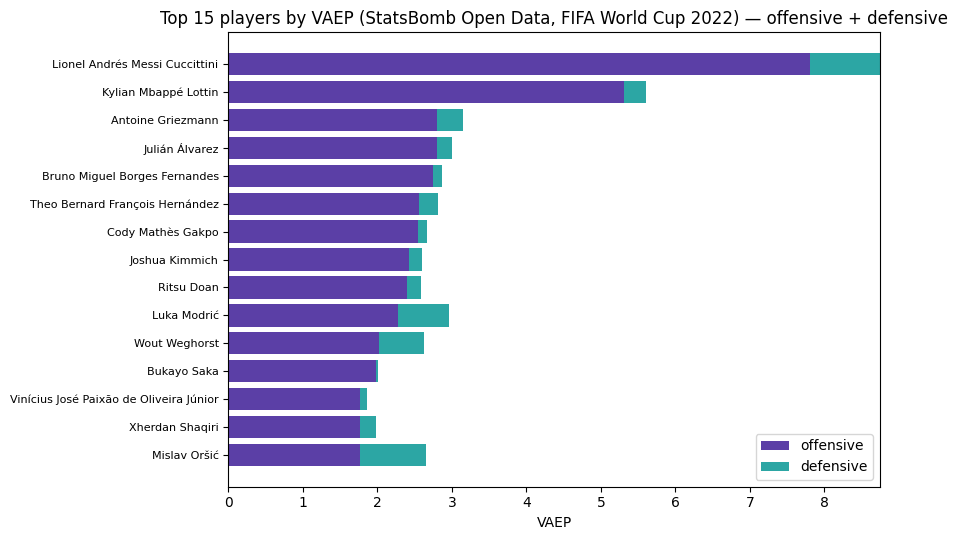

In [10]:
from vaep.train_statsbomb_vaep import aggregate_players
directory = statsbomb_actions.player_directory()
players = aggregate_players(scored, directory)

cols = ["player_name", "playing_position", "matches", "actions", "vaep",
        "offensive", "defensive", "goals"]
top = players.head(15)
display(top[cols].round(3))

fig, ax = plt.subplots(figsize=(9, 5.5))
t = top.iloc[::-1]
ax.barh(range(len(t)), t["offensive"], color="#5B3FA6", label="offensive")
ax.barh(range(len(t)), t["defensive"], left=t["offensive"], color="#2CA6A4", label="defensive")
ax.set_yticks(range(len(t))); ax.set_yticklabels(t["player_name"], fontsize=8)
ax.set_xlabel("VAEP"); ax.legend(loc="lower right")
ax.set_title("Top 15 players by VAEP (StatsBomb Open Data, FIFA World Cup 2022) — offensive + defensive")
plt.tight_layout(); plt.show()

## 9. The reusable package

Everything above is packaged for reuse and consistency with the other metrics:

- `vaep.statsbomb_actions` — download StatsBomb Open Data + build the SPADL action table
- `vaep.vaep_features` / `vaep.vaep_labels` / `vaep.vaep_model` / `vaep.vaep_formula`
- `vaep.train_statsbomb_vaep` — the whole pipeline end-to-end

```bash
python -m vaep.train_statsbomb_vaep            # download, train, score, and rate players
```

**Takeaways.** VAEP values every action in one currency and, unlike xThreat, credits
**defensive** actions too. The offensive/defensive split shows *how* a player adds value —
attackers via shots and progression, deep midfielders and defenders via safe build-up and
ball recovery. StatsBomb's real end coordinates and explicit carries also make the action
stream itself richer than a point-event feed like DFL/Sportec's — no reconstruction
needed. At World Cup 2022 scale the models are already reasonably well-calibrated; the
identical method on a full league season is what powers the K-League analysis.